In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [9]:
pd.set_option('display.float_format', '{:.2f}'.format)


In [10]:
df = pd.read_csv('ds_salaries.csv')
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [11]:
df.shape

(3755, 11)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [13]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.00,3755.00,3755.00,3755.00
mean,2022.37,190695.57,137570.39,46.27
std,0.69,671676.50,63055.63,48.59
min,2020.00,6000.00,5132.00,0.00
25%,2022.00,100000.00,95000.00,0.00
50%,2022.00,138000.00,135000.00,0.00
75%,2023.00,180000.00,175000.00,100.00
max,2023.00,30400000.00,450000.00,100.00


In [14]:
print('Number of duplicated rows: ', df.duplicated().sum())
print('Number of empty rows:\n', df.isnull().sum())

Number of duplicated rows:  1171
Number of empty rows:
 work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


In [23]:
df = df.drop_duplicates(keep='first')

## **Data Vizualization**

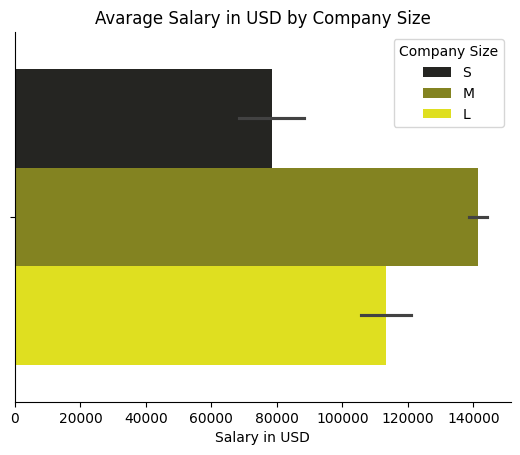

In [48]:
hue_order = ['S', 'M', 'L']
sns.barplot(data=df, x='salary_in_usd', hue='company_size', hue_order=hue_order, palette='dark:yellow')
plt.title('Avarage Salary in USD by Company Size')
plt.xlabel('Salary in USD')
plt.legend(title='Company Size')
sns.despine()
plt.show()

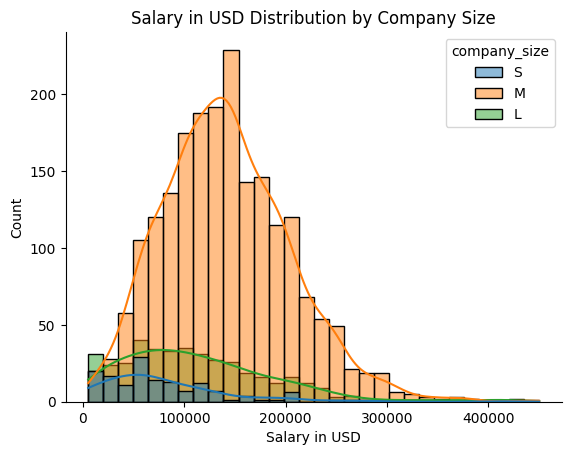

In [47]:
hue_order = ['S', 'M', 'L']
sns.histplot(data=df, x='salary_in_usd', hue='company_size', bins=30, kde=True, hue_order=hue_order, color='green')
plt.title('Salary in USD Distribution by Company Size')
plt.xlabel('Salary in USD')
sns.despine()
plt.show()

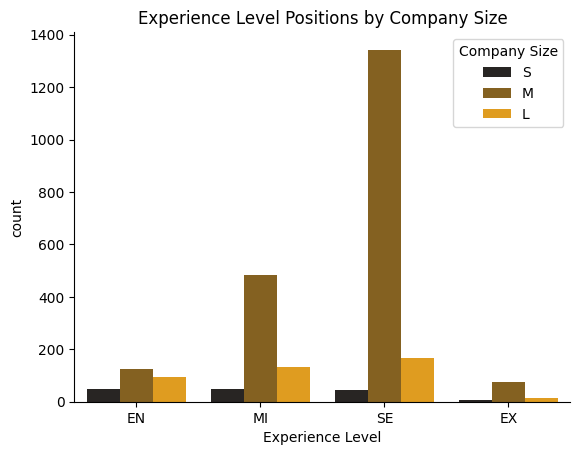

In [33]:
order = ['EN', 'MI', 'SE', 'EX']
hue_order = ['S', 'M', 'L']
sns.countplot(data=df, x='experience_level', hue='company_size', palette='dark:orange', order=order, hue_order=hue_order)
plt.title('Experience Level Positions by Company Size')
plt.xlabel('Experience Level')
plt.legend(title='Company Size')
sns.despine()
plt.show()

C:\Users\42060\AppData\Local\Temp\ipykernel_8564\4271325015.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_top, y='salary_in_usd', x='company_location',
C:\Users\42060\AppData\Local\Temp\ipykernel_8564\4271325015.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top, y='salary_in_usd', x='company_location',


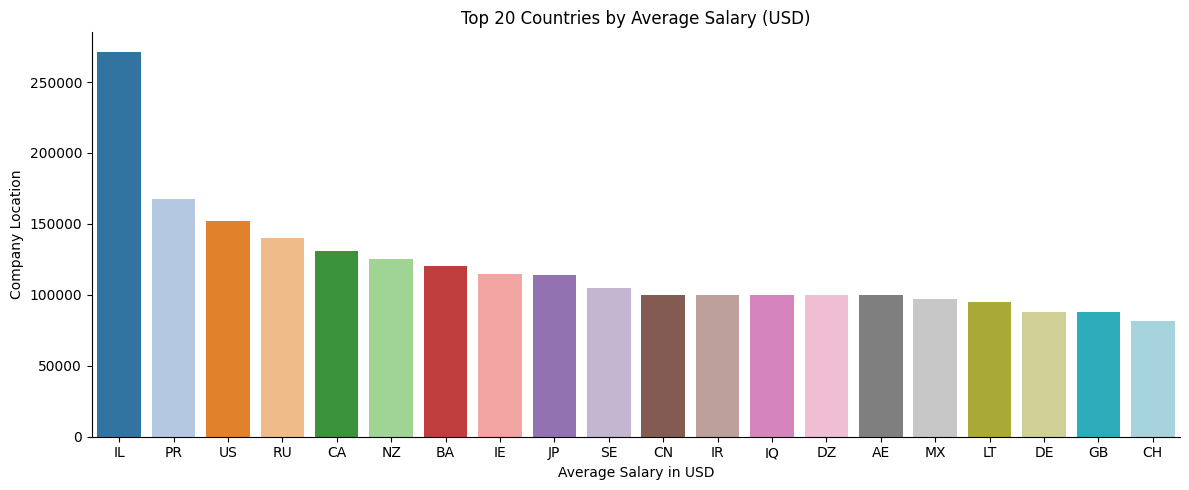

In [64]:
top_countries = df.groupby('company_location')['salary_in_usd'].mean().sort_values(ascending=False).head(20)
df_top = df[df['company_location'].isin(top_countries.index)]

plt.figure(figsize=(12, 5))
sns.barplot(data=df_top, y='salary_in_usd', x='company_location',
            order=top_countries.index, ci=None, palette=sns.color_palette('tab20', n_colors=20))
plt.title('Top 20 Countries by Average Salary (USD)')
plt.xlabel('Average Salary in USD')
plt.ylabel('Company Location')
sns.despine()
plt.tight_layout()
plt.show()

C:\Users\42060\AppData\Local\Temp\ipykernel_8564\4053311529.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_worst, y='salary_in_usd', x='company_location',
C:\Users\42060\AppData\Local\Temp\ipykernel_8564\4053311529.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_worst, y='salary_in_usd', x='company_location',


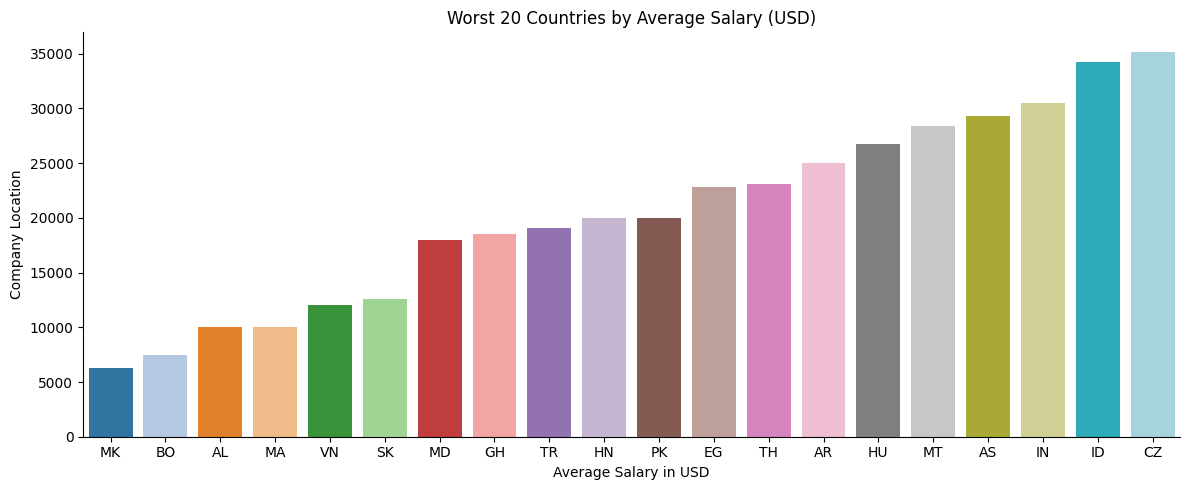

In [71]:
worst_countries = df.groupby('company_location')['salary_in_usd'].mean().sort_values(ascending=True).head(20)
df_worst = df[df['company_location'].isin(worst_countries.index)]

plt.figure(figsize=(12, 5))
sns.barplot(data=df_worst, y='salary_in_usd', x='company_location',
            order=worst_countries.index, ci=None, palette=sns.color_palette('tab20', n_colors=20))
plt.title('Worst 20 Countries by Average Salary (USD)')
plt.xlabel('Average Salary in USD')
plt.ylabel('Company Location')
sns.despine()
plt.tight_layout()
plt.show()

In [72]:
df.employment_type.unique()

array(['FT', 'CT', 'FL', 'PT'], dtype=object)

In [73]:
df.company_location.unique()

array(['ES', 'US', 'CA', 'DE', 'GB', 'NG', 'IN', 'HK', 'NL', 'CH', 'CF',
       'FR', 'FI', 'UA', 'IE', 'IL', 'GH', 'CO', 'SG', 'AU', 'SE', 'SI',
       'MX', 'BR', 'PT', 'RU', 'TH', 'HR', 'VN', 'EE', 'AM', 'BA', 'KE',
       'GR', 'MK', 'LV', 'RO', 'PK', 'IT', 'MA', 'PL', 'AL', 'AR', 'LT',
       'AS', 'CR', 'IR', 'BS', 'HU', 'AT', 'SK', 'CZ', 'TR', 'PR', 'DK',
       'BO', 'PH', 'BE', 'ID', 'EG', 'AE', 'LU', 'MY', 'HN', 'JP', 'DZ',
       'IQ', 'CN', 'NZ', 'CL', 'MD', 'MT'], dtype=object)